#**REAL-TIME ANALYSIS AND MODEL TRAINING USING CIC-DARKNET2020 DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pandas numpy scikit-learn xgboost matplotlib shap


In [ ]:
# train-test split evaluation of xgboost model
from numpy import loadtxt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Digital_Forensics/Darknet.xlsx')


In [ ]:

# Step 2: Drop Unnecessary Columns
df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp','Src Port','Dst Port','Flow Duration','Idle Mean','Idle Std','Idle Max','Idle Min'], errors='ignore', inplace=True)
# Drop all Unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.dropna(inplace=True)

In [ ]:
df.loc[df["Type"] == "Non-Tor", "Encryption"] = "Standard"
df.loc[df["Type"] == "NonVPN", "Encryption"] = "Standard"
df.loc[df["Type"] == "Tor", "Encryption"] = "High"
df.loc[df["Type"] == "VPN", "Encryption"] = "High"
df

,Protocol,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Type,Label,Encryption
0,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,Standard
1,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,Standard
2,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,Standard
3,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,Standard
4,6,591,400,64530,6659,131,0,109.187817,22.283313,498,...,2320,581,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141526,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,High
141527,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,High
141528,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,High
141529,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,High


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction import DictVectorizer as labBin
from sklearn.preprocessing import LabelEncoder


df["Encryption"] = df["Encryption"].map({"Standard":0, "High":1})
df

,Protocol,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Type,Label,Encryption
0,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,0.0
1,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,0.0
2,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,0.0
3,6,1,1,0,0,0,0,0.000000,0.000000,0,...,1047,0,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,0.0
4,6,591,400,64530,6659,131,0,109.187817,22.283313,498,...,2320,581,20,0,0,0,0,Non-Tor,AUDIO-STREAMING,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141526,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,1.0
141527,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,1.0
141528,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,1.0
141529,17,2,0,44,0,22,22,22.000000,0.000000,0,...,0,1,8,0,0,0,0,VPN,VOIP,1.0


In [ ]:
target_col = "Encryption"
X = df.loc[:, df.columns != target_col]
y = df.loc[:, target_col]
X = X.select_dtypes(include=["int64", "float64", "bool"])

In [ ]:
import numpy as np

# # # Replace inf/-inf with NaN
# X = X.replace([np.inf, -np.inf], np.nan)

# # # Drop columns with any NaN values
# # X = X.dropna(axis=1)
# X = X.apply(pd.to_numeric, errors='coerce')  # forces non-numeric to NaN
# # X = X.dropna(axis=1)  # drop columns that now contain NaN due to coercion

# Convert all values to numeric (non-convertible become NaN)
X = X.apply(pd.to_numeric, errors='coerce')

# Replace inf and -inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Optional: Drop rows with too many NaNs (e.g., keep rows with at least 90% valid data)
X = X.dropna(thresh=int(X.shape[1] * 0.9))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)



In [ ]:
# fit model no training data
model = XGBClassifier()
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# First, ensure X_test and y_test are aligned and clean
X_test = X_test.copy()
y_test = y_test.copy()

# Drop any NaNs in y_test and corresponding rows in X_test
mask = ~y_test.isna()
X_test = X_test[mask]
y_test = y_test[mask]

# Now predict and evaluate
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 97.85%


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Compute additional metrics
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

# Print metrics
print("Precision: %.4f" % precision)
print("Recall   : %.4f" % recall)
print("F1 Score : %.4f" % f1)
print("AUC      : %.4f" % auc)

Precision: 0.9501
Recall   : 0.9254
F1 Score : 0.9376
AUC      : 0.9967


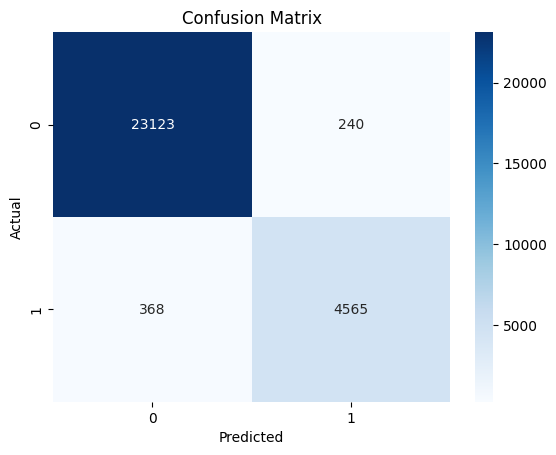

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

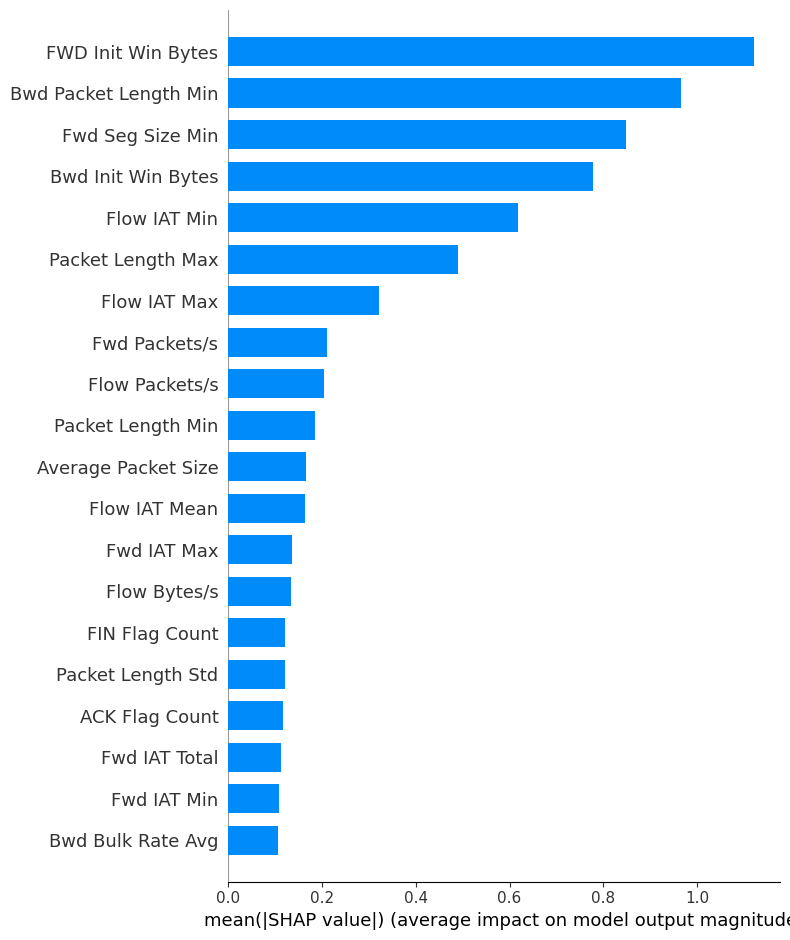

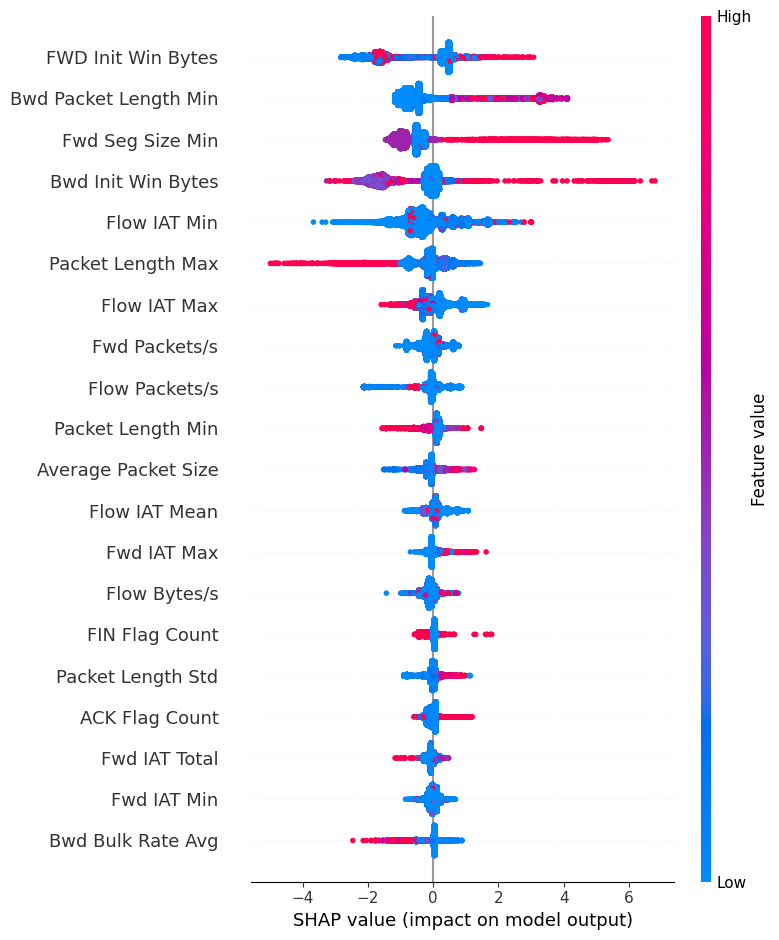

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP TreeExplainer
explainer = shap.Explainer(model)

# Compute SHAP values for test set
shap_values = explainer(X_test)

# Summary plot: shows top contributing features
shap.summary_plot(shap_values, X_test, plot_type="bar")  # Feature importance

# Optional: full summary (beeswarm)
shap.summary_plot(shap_values, X_test)

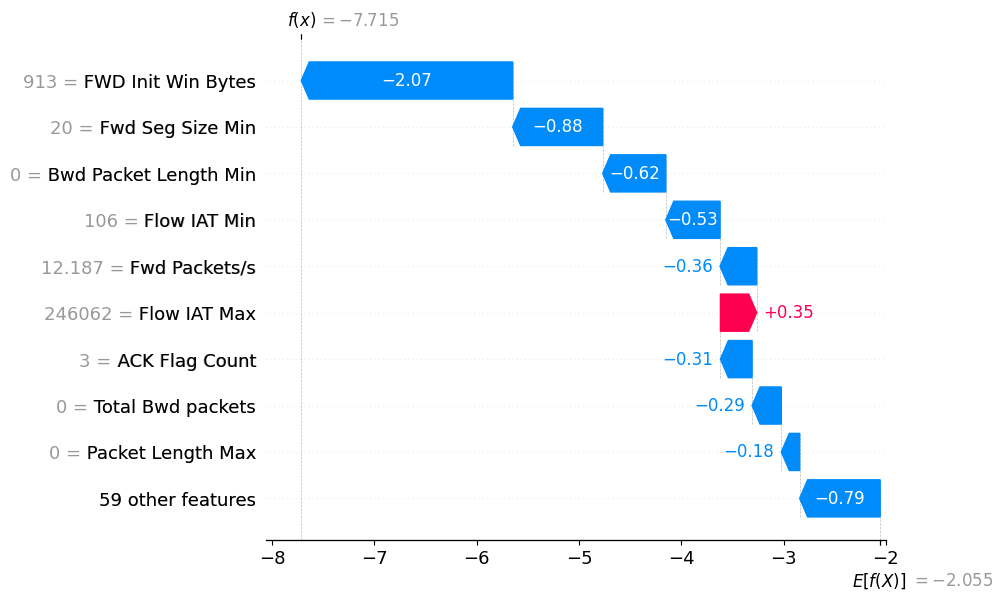

In [ ]:
# Show explanation for one test instance (e.g., the 5th sample)
shap.plots.waterfall(shap_values[5])


In [ ]:
import shap

# JS visualization support
shap.initjs()

shap_values_batch = explainer(X.iloc[:1000])

# This works for arrays of Explanation objects
shap.force_plot(shap_values_batch)


In [ ]:
import joblib

joblib.dump(model, "/content/drive/MyDrive/Digital_Forensics/xgb_model/xgb_model2.joblib")
joblib.dump(list(X_train.columns), "/content/drive/MyDrive/Digital_Forensics/xgb_model/expected_columns2.pkl")

['/content/drive/MyDrive/Digital_Forensics/xgb_model/expected_columns2.pkl']

#Real-time analysis using cicflowmeter
###Code

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# --- Config ---
csv_path = "Book1.csv"  # ⬅️ Your new CSV with Label + Prediction

# --- Load the file ---
df = pd.read_csv(csv_path)

# --- Map string labels to integers ---
label_map = {
    "Benign": 0,
    "DARKNET": 1,
    "Darknet": 1,
    "darknet": 1
}

df["Label"] = df["Label"].map(label_map)

# --- Sanity check ---
if "encryption" not in df.columns or df["Label"].isnull().any():
    print("❌ Error: Missing 'encryption' column or unmapped labels.")
    exit(1)

# --- Extract columns ---
y_true = df["Label"]
y_pred = df["encryption"]

# --- Evaluate ---
print("✅ Accuracy:", accuracy_score(y_true, y_pred))
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Benign", "Darknet"]))

###Output
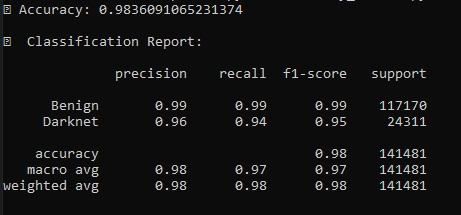